In [ ]:
''' Data Wrangling II 
Create an “Academic performance” dataset of students and perform the following operations using 
Python. 
 
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or 
inconsistencies, use any of the suitable techniques to deal with them.   
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable 
techniques to deal with them.  
3. Apply data transformations on at least one of the variables. The purpose of this 
transformation should be one of the following reasons: to change the scale for better 
understanding of the variable, to convert a non-linear relation into a linear one, or to 
decrease the skewness and convert the distribution into a normal distribution.  
 
Reason and document your approach properly.''' 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Create Synthetic Academic Performance Dataset
np.random.seed(42)
n_students = 50

data = {
    'Student_ID': range(1, n_students + 1),
    'Gender': np.random.choice(['M', 'F'], n_students),
    'Math_Score': np.random.randint(40, 100, n_students).astype(float),
    'Reading_Score': np.random.randint(40, 100, n_students).astype(float),
    'Writing_Score': np.random.randint(40, 100, n_students).astype(float),
    'Placement_Score': np.random.randint(50, 100, n_students).astype(float),
    'Attendance': np.random.randint(60, 100, n_students).astype(float)
}

df = pd.DataFrame(data)

# Introduce Missing Values
df.loc[5, 'Math_Score'] = np.nan
df.loc[10, 'Reading_Score'] = np.nan
df.loc[15, 'Placement_Score'] = np.nan

# Introduce Inconsistencies (e.g., scores > 100 or negative)
df.loc[20, 'Math_Score'] = 500
df.loc[25, 'Reading_Score'] = -10

display(df.head())

,Student_ID,Gender,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance
0,1,M,86.0,49.0,80.0,94.0,62.0
1,2,F,90.0,75.0,67.0,64.0,96.0
2,3,M,83.0,53.0,46.0,92.0,76.0
3,4,M,94.0,70.0,48.0,78.0,61.0
4,5,M,91.0,87.0,47.0,85.0,61.0


In [5]:
# 1. Handling Missing Values and Inconsistencies

df.loc[(df['Math_Score'] > 100) | (df['Math_Score'] < 0), 'Math_Score'] = np.nan
df.loc[(df['Reading_Score'] > 100) | (df['Reading_Score'] < 0), 'Reading_Score'] = np.nan

df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].median())
df['Reading_Score'] = df['Reading_Score'].fillna(df['Reading_Score'].median())
df['Placement_Score'] = df['Placement_Score'].fillna(df['Placement_Score'].median())

print("Missing values after cleaning:")
print(df.isnull().sum())
display(df.describe())

Missing values after cleaning:
Student_ID         0
Gender             0
Math_Score         0
Reading_Score      0
Writing_Score      0
Placement_Score    0
Attendance         0
dtype: int64


,Student_ID,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,70.300000,68.500000,67.680000,75.880000,78.600000
std,14.57738,18.633961,17.724651,15.943062,14.345077,12.822175
min,1.00000,41.000000,40.000000,40.000000,50.000000,60.000000
25%,13.25000,53.750000,54.000000,53.250000,62.500000,65.250000
50%,25.50000,73.500000,64.500000,70.000000,77.000000,78.000000
75%,37.75000,86.000000,83.750000,78.000000,88.000000,91.000000
max,50.00000,99.000000,99.000000,99.000000,98.000000,99.000000


In [6]:
# 2. Scan and Handle Outliers using IQR Method

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

for col in ['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score']:
    df = handle_outliers(df, col)

print("Outliers handled using IQR bounds.")
display(df.describe())

Outliers handled using IQR bounds.


,Student_ID,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,70.300000,68.500000,67.680000,75.880000,78.600000
std,14.57738,18.633961,17.724651,15.943062,14.345077,12.822175
min,1.00000,41.000000,40.000000,40.000000,50.000000,60.000000
25%,13.25000,53.750000,54.000000,53.250000,62.500000,65.250000
50%,25.50000,73.500000,64.500000,70.000000,77.000000,78.000000
75%,37.75000,86.000000,83.750000,78.000000,88.000000,91.000000
max,50.00000,99.000000,99.000000,99.000000,98.000000,99.000000


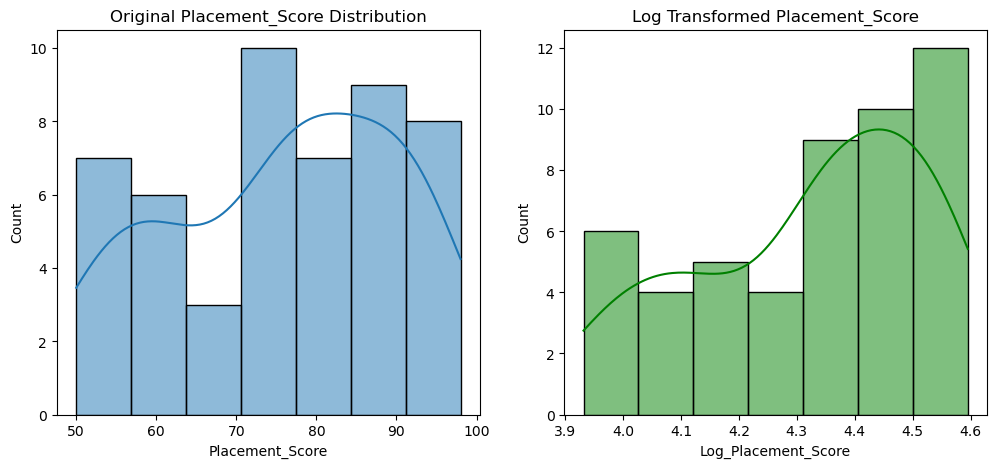

,Placement_Score,Log_Placement_Score
0,94.0,4.553877
1,64.0,4.174387
2,92.0,4.532599
3,78.0,4.369448
4,85.0,4.454347


In [7]:
# 3. Data Transformation

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Placement_Score'], kde=True)
plt.title('Original Placement_Score Distribution')

# Applying Log Transformation
df['Log_Placement_Score'] = np.log1p(df['Placement_Score'])

plt.subplot(1, 2, 2)
sns.histplot(df['Log_Placement_Score'], kde=True, color='green')
plt.title('Log Transformed Placement_Score')

plt.show()

display(df[['Placement_Score', 'Log_Placement_Score']].head())